<a href="https://colab.research.google.com/github/edgarango/Proyecto-MIAD-Grupo8/blob/main/Proyecto_Sinistros_G8V4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto Aplicado: Predicción y Análisis Espacial de la Severidad de Siniestros Viales en Bogotá D.C.**
Maestría en Inteligencia Analítica de Datos (MIAD)
Elaborado por:

**1. Contexto del Problema y Enfoque Analítico**


La seguridad vial en entornos urbanos densos representa uno de los mayores desafíos para la salud pública y la gestión de operaciones de emergencia. En Bogotá, la siniestralidad no se distribuye de manera uniforme, y una gran proporción de los incidentes resulta en personas lesionadas. La asignación ineficiente de recursos de atención (ambulancias, grúas, personal de tránsito) durante las ventanas de tiempo críticas puede significar la diferencia entre un incidente controlado y una fatalidad.

**Objetivo del Artefacto:** El objetivo de este proyecto es diseñar e implementar un artefacto analítico que permita anticipar la severidad de un siniestro vial (clasificado en Solo Daños, Con Heridos o Con Muertos) en función de variables temporales, geográficas y la naturaleza de los actores viales involucrados.

**Selección del Enfoque Analítico:**

Para responder a los requerimientos del problema, se plantea una solución híbrida:

* Modelado Descriptivo (Aprendizaje No Supervisado): Se implementará un algoritmo de Clustering (K-Means) sobre las coordenadas geográficas de los incidentes. El objetivo no es predecir, sino descubrir patrones espaciales inherentes a los datos para mapear "hotspots" o zonas de riesgo crítico, superando las limitaciones de las divisiones políticas tradicionales (localidades).

* Modelado Predictivo (Clasificación Supervisada): Para responder a la pregunta "¿Cuál es el riesgo de fatalidad dado un escenario específico?", se implementarán y compararán modelos de clasificación. Dada la necesidad de capturar interacciones complejas y no lineales entre los actores viales y el entorno, se priorizará el uso de algoritmos basados en árboles y ensambles (como Random Forest y LightGBM), balanceados algorítmicamente para manejar la extrema minoría de los eventos fatales.

**2. Librerias y carga de datos**

In [ ]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y CARGA DE DATOS
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import geopandas as gpd
import plotly.express as px
from folium.plugins import HeatMap
from folium.features import DivIcon, GeoJsonTooltip
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import time
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import label_binarize
import warnings

# Configuración Visual
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 11})

print("Iniciando carga de datos...")

# Ruta del archivo (Ajustar según ubicación en Drive/Colab)
ruta = '/content/base-anuario-de-siniestralidad-2024.xlsx'

# Carga de todas las hojas de la base de datos oficial
df_siniestros = pd.read_excel(ruta, sheet_name='Siniestros')
df_vehiculos = pd.read_excel(ruta, sheet_name='Vehiculos')
df_actores = pd.read_excel(ruta, sheet_name='Actor_vial')
df_diccionario = pd.read_excel(ruta, sheet_name='Diccionario')

print(f"✅ Datos cargados exitosamente. Registros totales en Siniestros: {df_siniestros.shape[0]}")

Iniciando carga de datos...
✅ Datos cargados exitosamente. Registros totales en Siniestros: 82371


**2. Análisis del Diccionario y Verificación de Datos**


Antes de limpiar, analizamos la definición de las variables y verificamos que los tipos de datos asignados por Python coincidan con su naturaleza técnica.

In [ ]:
# ==============================================================================
# 2. ANÁLISIS Y VERIFICACIÓN DE DATOS
# ==============================================================================

print("--- ANÁLISIS DEL DICCIONARIO ---")
display(df_diccionario.head(10)) # Mostramos las primeras 10 para no saturar la pantalla

print("\n--- VERIFICACIÓN DE TIPOS DE DATOS (dtypes) ---")
display(df_siniestros.dtypes)

# Verificamos específicamente las coordenadas y horas
cols_verificar = ['Latitud', 'Longitud', 'Hora_Acc', 'AA_Acc']
print("\n--- MUESTRA DE VARIABLES CRÍTICAS ---")
display(df_siniestros[cols_verificar].head())

--- ANÁLISIS DEL DICCIONARIO ---


,Hoja,Atributo,Descripción
0,Siniestros,Codigo_Accidente,Clave primaria del ipat
1,Siniestros,Formulario,Número del Informe Policial de Accidente de Tr...
2,Siniestros,Longitud,Coordenada geográfica que indica la distancia ...
3,Siniestros,Latitud,Coordenada geográfica que indica la distancia ...
4,Siniestros,Direccion,Dirección completa donde ocurrió el siniestro ...
5,Siniestros,Fecha_Acc,Fecha en que ocurrió el siniestro vial (día-me...
6,Siniestros,AA_Acc,Año en que ocurrió el siniestro vial
7,Siniestros,MM_Acc,"Mes en que ocurrió el siniestro vial (Enero, F..."
8,Siniestros,DD_Mes_Acc,Día del mes en que ocurrió el siniestro vial
9,Siniestros,Dia_Semana_Acc,Día de la semana en que ocurrió el siniestro v...



--- VERIFICACIÓN DE TIPOS DE DATOS (dtypes) ---


,0
Codigo_Accidente,int64
Formulario,object
Longitud,float64
Latitud,float64
Direccion,object
Fecha_Acc,datetime64[ns]
AA_Acc,int64
MM_Acc,object
DD_Mes_Acc,int64
Dia_Semana_Acc,object



--- MUESTRA DE VARIABLES CRÍTICAS ---


,Latitud,Longitud,Hora_Acc,AA_Acc
0,4.578244,-74.085897,18,2021
1,4.709911,-74.079980,8,2021
2,4.633219,-74.079344,12,2021
3,4.618746,-74.139532,4,2021
4,4.544145,-74.120839,12,2021


**3. Preparación de Datos y Verificación de Supuestos Operativos**

La base de datos original consta de registros relacionales divididos en tablas de Siniestros, Vehículos y Actores Viales. Para garantizar que los algoritmos de Machine Learning operen sobre una representación fiel de la realidad de las vías, establecemos los siguientes pasos de consolidación:

* Aplanamiento Relacional: Consolidamos la información contando el número total de vehículos involucrados por evento, inyectando esta variable derivada a la matriz principal.

* Imputación Lógica de Condiciones: En las bases de datos de tránsito, la ausencia de un registro en las variables de actores (ej. Con_Moto, Con_Peaton) indica la no participación de dicho actor. Estas variables se transforman exhaustivamente a un formato binario (1 y 0).

* Aislamiento Geográfico: Filtramos las coordenadas GPS para restringir los datos al Bounding Box oficial de Bogotá, eliminando ruido introducido por errores de digitación espacial.

In [ ]:
# ==============================================================================
# 3. PREPARACIÓN DE DATOS E INGENIERÍA DE CARACTERÍSTICAS
# ==============================================================================

print("Iniciando procesamiento e ingeniería de características...")

# 1. Integración del número de vehículos involucrados
conteo_veh = df_vehiculos.groupby('Codigo_Accidente').size().reset_index(name='Num_Vehiculos_Involucrados')
df_ml = df_siniestros.merge(conteo_veh, on='Codigo_Accidente', how='left')
df_ml['Num_Vehiculos_Involucrados'] = df_ml['Num_Vehiculos_Involucrados'].fillna(0)

# 2. Limpieza de Coordenadas y Horas
df_ml['Hora_Acc'] = pd.to_numeric(df_ml['Hora_Acc'], errors='coerce')
df_ml = df_ml.dropna(subset=['Hora_Acc', 'Gravedad_Indicador_Tradicional', 'Latitud', 'Longitud'])

# Filtrar coordenadas válidas para Bogotá (Aprox: Lat 4.4 a 4.9, Lon -74.3 a -73.9)
df_ml = df_ml[(df_ml['Latitud'] > 4.4) & (df_ml['Latitud'] < 4.9) &
              (df_ml['Longitud'] > -74.3) & (df_ml['Longitud'] < -73.9)]

# 3. Binarización dinámica de TODAS las variables condicionales (Actores, embriaguez, exceso velocidad, etc.)
columnas_condicion = [col for col in df_ml.columns if str(col).startswith('Con_')]
for col in columnas_condicion:
    df_ml[col] = df_ml[col].apply(lambda x: 1 if x == 'SI' else 0)

# 4. Extracción Temporal (Creación de Mes Numérico)
mapa_meses = {'Enero':1, 'Febrero':2, 'Marzo':3, 'Abril':4, 'Mayo':5, 'Junio':6,
              'Julio':7, 'Agosto':8, 'Septiembre':9, 'Octubre':10, 'Noviembre':11, 'Diciembre':12}
df_ml['Mes_Num'] = df_ml['MM_Acc'].map(mapa_meses)

print(f"✅ Preprocesamiento completado. Base analítica final: {df_ml.shape[0]} registros.")

Iniciando procesamiento e ingeniería de características...
✅ Preprocesamiento completado. Base analítica final: 82361 registros.


**4. Análisis Exploratorio de Datos (EDA) y Patrones Geográficos**


Antes de avanzar a las etapas de modelado y agrupación espacial (Clustering), exploramos el comportamiento de la siniestralidad desde tres dimensiones clave:

* El Desbalanceo de Severidad: Nuestra variable a predecir.

* Dinámica Temporal: Distribución estacional (mes/día) y cálculo de la carga operativa crítica por hora (Q3).

* Distribución Geográfica Tradicional: Análisis por localidades y mapeo interactivo de la ciudad.

Generando análisis exploratorio descriptivo...


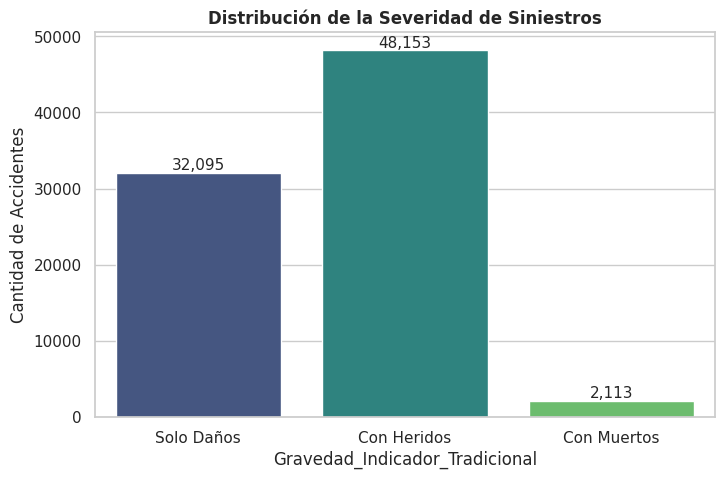

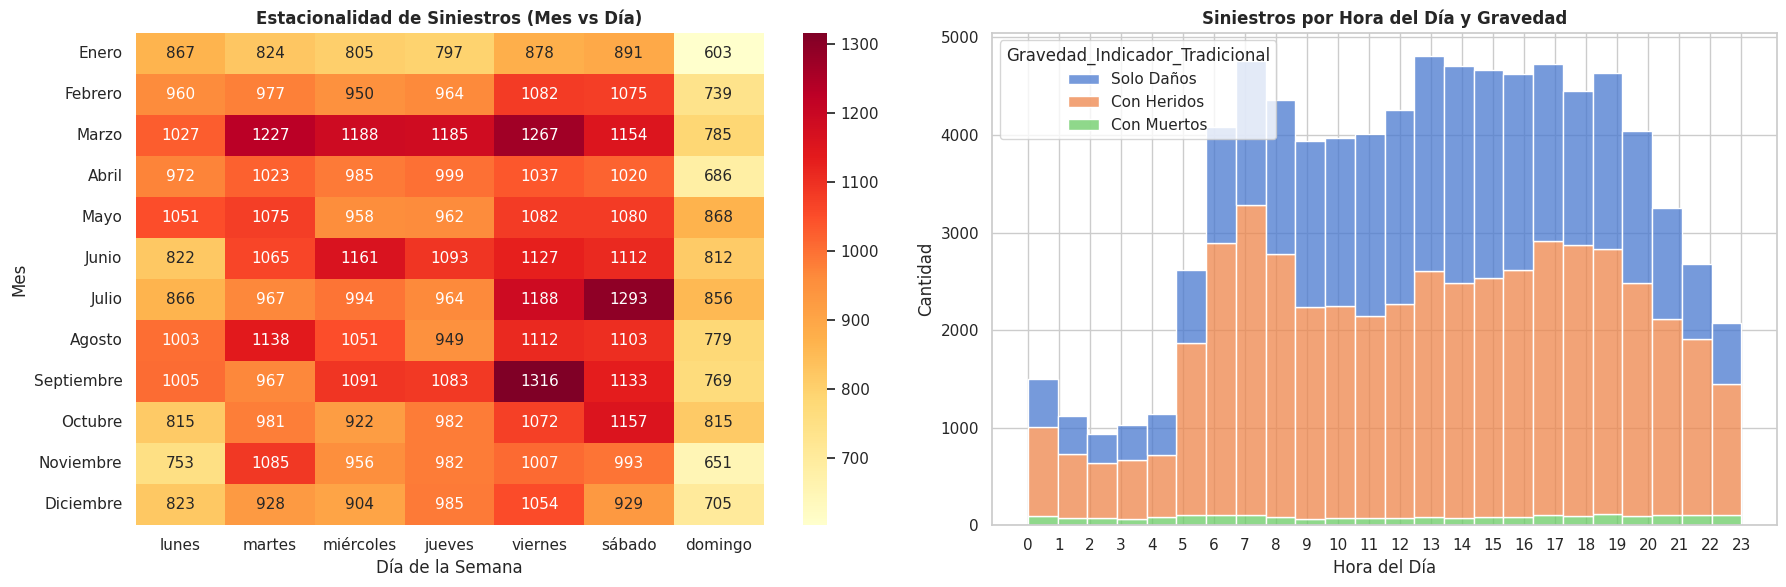


Identificación de Horas de Carga Crítica Operativa
Volumen Promedio por hora: 490.2 siniestros
Umbral Crítico (Q3): 667.2 siniestros


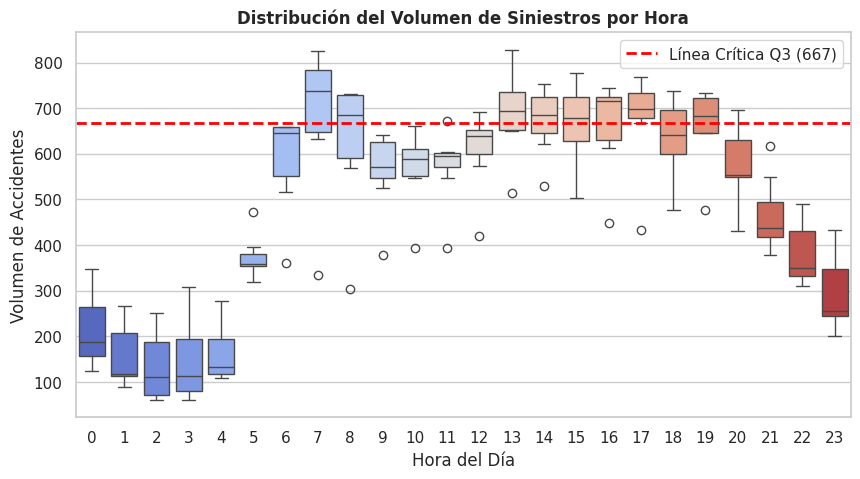


Generando Mapa de Correlaciones y Tabla de Valores...


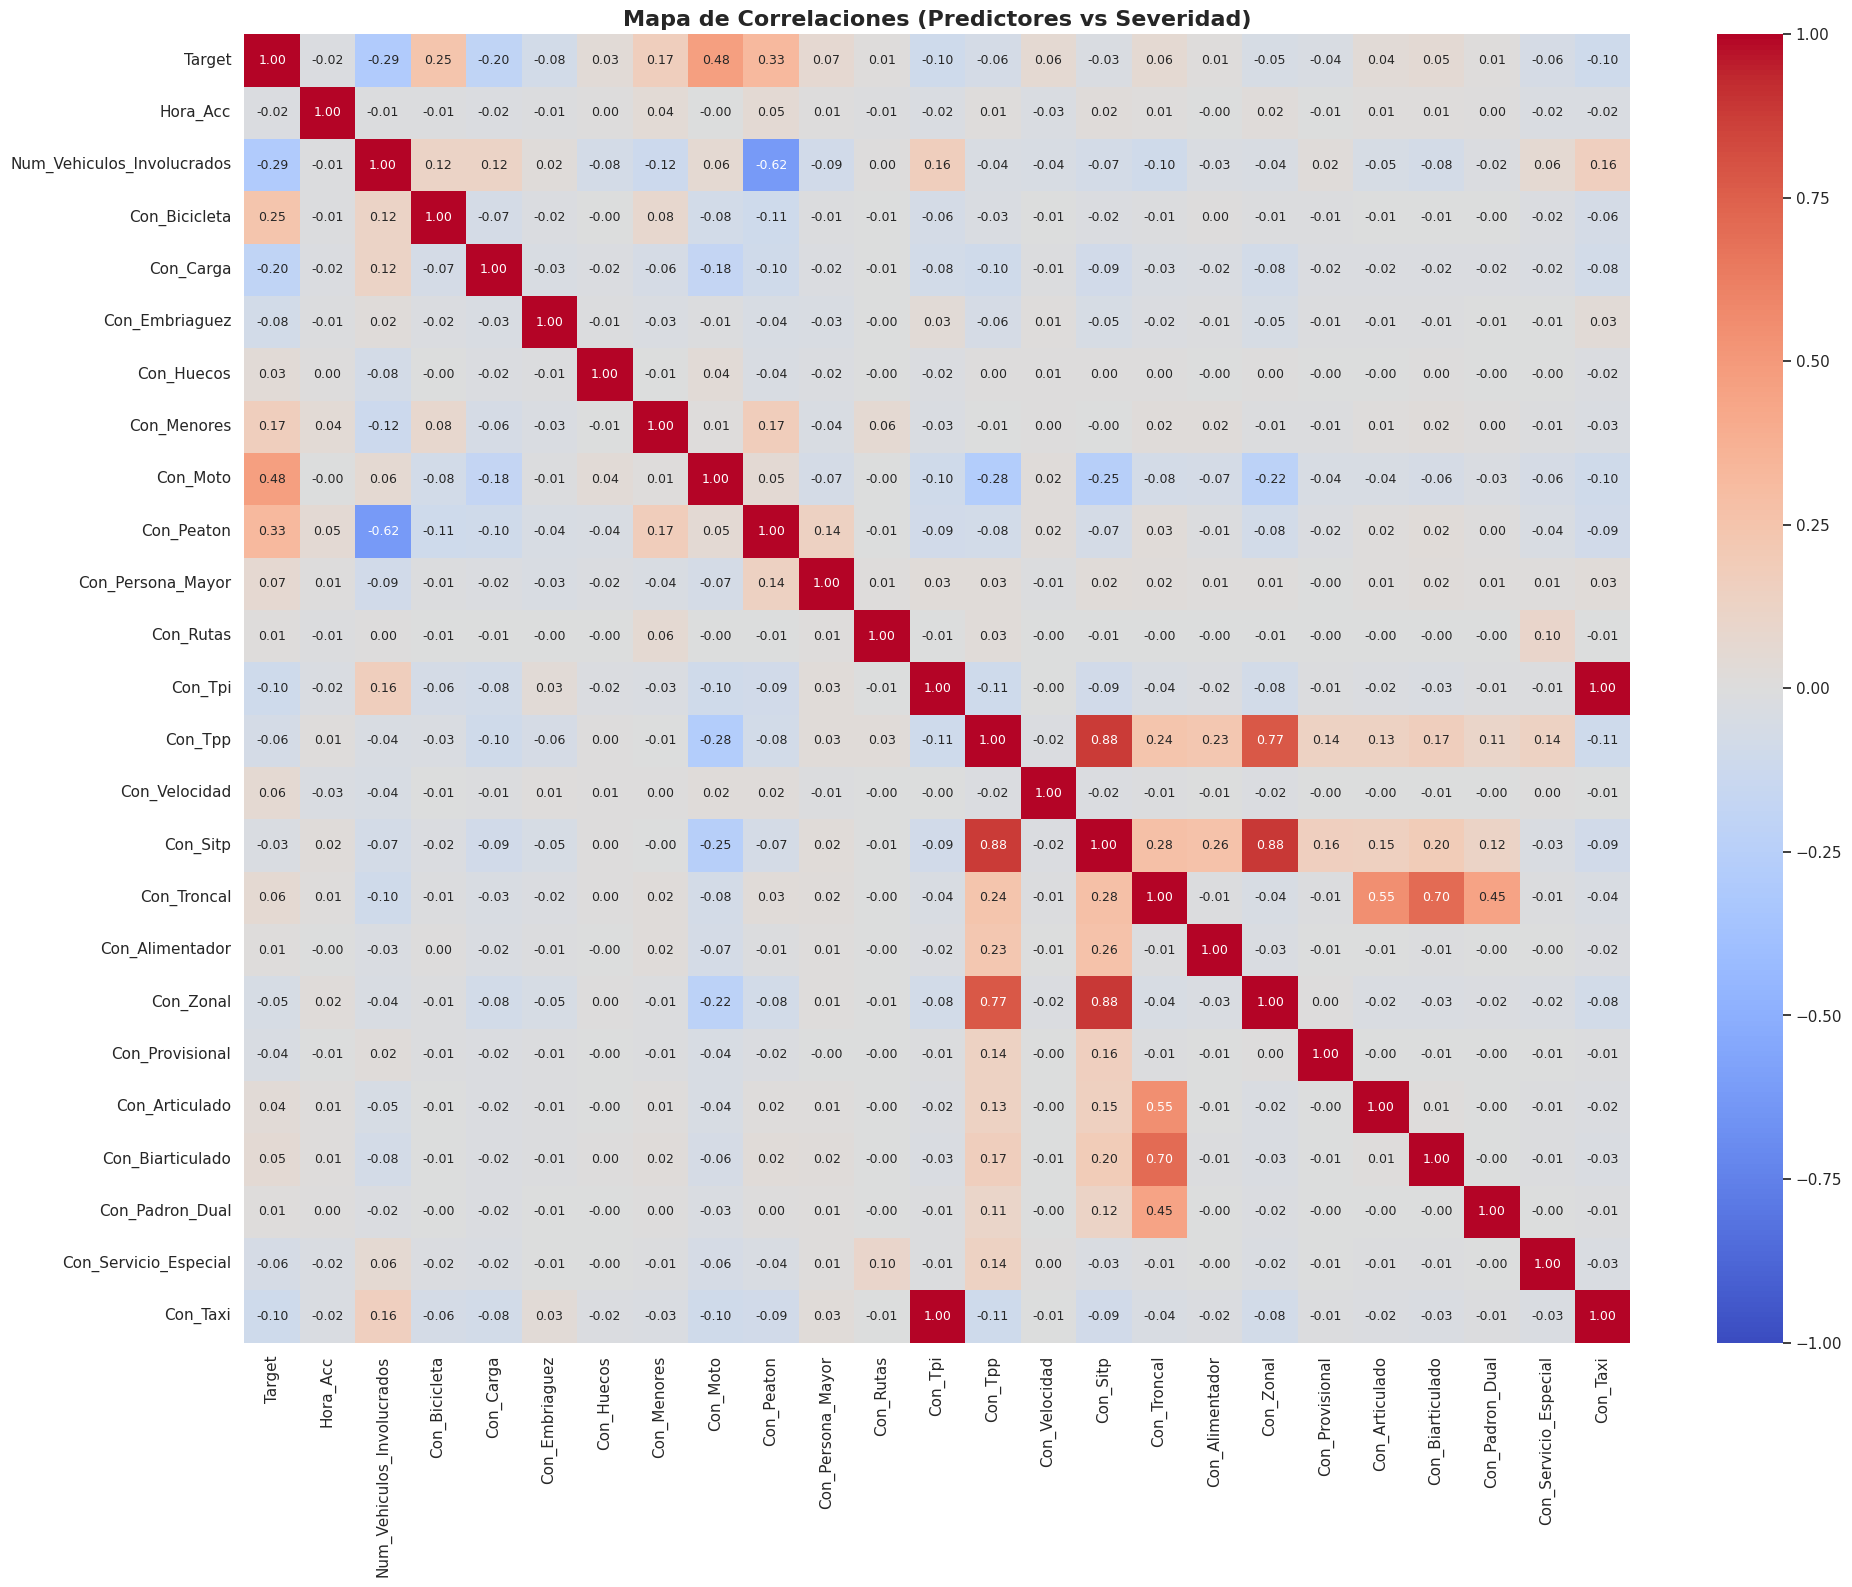


📊 TABLA DE CORRELACIONES CON LA GRAVEDAD DEL SINIESTRO (Target):


,Target
Target,1.000
Con_Moto,0.476
Con_Peaton,0.328
Con_Bicicleta,0.246
Con_Menores,0.166
Con_Persona_Mayor,0.068
Con_Troncal,0.059
Con_Velocidad,0.058
Con_Biarticulado,0.049
Con_Articulado,0.038


In [ ]:
# ==============================================================================
# 4. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==============================================================================

print("Generando análisis exploratorio descriptivo...")

# --- A. Distribución de Severidad (Target) ---
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_ml, x='Gravedad_Indicador_Tradicional', palette='viridis')
plt.title('Distribución de la Severidad de Siniestros', fontweight='bold')
plt.ylabel('Cantidad de Accidentes')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.show()

# --- B. Análisis Temporal (Estacionalidad y Hora) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# B.1 Mapa de Calor Estacional
pivot_estacional = df_ml.pivot_table(index='MM_Acc', columns='Dia_Semana_Acc', values='Codigo_Accidente', aggfunc='count')
orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
orden_dias = ['lunes', 'martes', 'miércoles', 'jueves', 'viernes', 'sábado', 'domingo']
pivot_estacional = pivot_estacional.reindex(index=orden_meses, columns=orden_dias)

sns.heatmap(pivot_estacional, annot=True, fmt="d", cmap="YlOrRd", ax=axes[0])
axes[0].set_title('Estacionalidad de Siniestros (Mes vs Día)', fontweight='bold')
axes[0].set_xlabel('Día de la Semana')
axes[0].set_ylabel('Mes')

# B.2 Siniestros por Hora y Gravedad
sns.histplot(data=df_ml, x='Hora_Acc', bins=24, hue='Gravedad_Indicador_Tradicional', multiple="stack", ax=axes[1])
axes[1].set_title('Siniestros por Hora del Día y Gravedad', fontweight='bold')
axes[1].set_xticks(range(0, 24))
axes[1].set_xlabel('Hora del Día')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

# --- C. ANÁLISIS DE CARGA CRÍTICA (Q3) ---
print("\nIdentificación de Horas de Carga Crítica Operativa")

volumen_horario = df_ml.groupby(['Dia_Semana_Acc', 'Hora_Acc']).size().reset_index(name='Volumen')
q3_volumen = volumen_horario['Volumen'].quantile(0.75)
media_volumen = volumen_horario['Volumen'].mean()

print(f"Volumen Promedio por hora: {media_volumen:.1f} siniestros")
print(f"Umbral Crítico (Q3): {q3_volumen:.1f} siniestros")

plt.figure(figsize=(10, 5))
sns.boxplot(data=volumen_horario, x='Hora_Acc', y='Volumen', palette='coolwarm')
plt.axhline(q3_volumen, color='red', linestyle='--', linewidth=2, label=f'Línea Crítica Q3 ({q3_volumen:.0f})')
plt.title('Distribución del Volumen de Siniestros por Hora', fontweight='bold')
plt.xlabel('Hora del Día')
plt.ylabel('Volumen de Accidentes')
plt.legend()
plt.show()

# --- D. MAPA DE CORRELACIONES (Matriz Completa y Valores) ---
print("\nGenerando Mapa de Correlaciones y Tabla de Valores...")

# Primero creamos la variable 'Target' numérica temporal para correlacionar
mapa_target = {'Solo Daños': 0, 'Con Heridos': 1, 'Con Muertos': 2}
df_ml['Target'] = df_ml['Gravedad_Indicador_Tradicional'].map(mapa_target)

# Seleccionamos variables numéricas relevantes
variables_binarias = [col for col in df_ml.columns if col.startswith('Con_')]
cols_corr = ['Target', 'Hora_Acc', 'Num_Vehiculos_Involucrados'] + variables_binarias

# Calculamos la matriz de correlación de Spearman
matriz_corr = df_ml[cols_corr].corr(method='spearman')

# Visualización del Mapa de Calor CON valores (annot=True)
plt.figure(figsize=(20, 16)) # Aumentamos el tamaño para que los números no se amontonen
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, annot_kws={"size": 9})
plt.title('Mapa de Correlaciones (Predictores vs Severidad)', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

# --- GENERACIÓN DE LA TABLA DE VALORES PARA ANÁLISIS ---
print("\n📊 TABLA DE CORRELACIONES CON LA GRAVEDAD DEL SINIESTRO (Target):")
# Extraemos solo la columna 'Target' y la ordenamos de mayor a menor
correlaciones_target = matriz_corr[['Target']].sort_values(by='Target', ascending=False)
display(correlaciones_target.round(3))

**4.1. Análisis de Correlaciones: Hallazgos Clave (Insights)**

La matriz de correlación de Spearman revela matemáticamente cuáles son los factores que impulsan la severidad de un accidente hacia la fatalidad (valores positivos) y cuáles lo inclinan hacia los choques de "Solo Daños" (valores negativos).

1. El Eje de la Vulnerabilidad (Correlación Positiva Alta):
Los tres predictores más fuertes de letalidad y lesiones en Bogotá son la presencia de motociclistas (0.476), peatones (0.328) y ciclistas (0.246). Esto significa que si un accidente involucra a uno de estos actores, la probabilidad estadística de que haya sangre o pérdida de vidas se dispara. El modelo predictivo seguramente asignará el mayor peso a estas tres variables.

2. La Paradoja de los Choques Múltiples (Correlación Negativa):
El hallazgo más contraintuitivo pero revelador es que el Num_Vehiculos_Involucrados tiene una fuerte correlación negativa (-0.291). ¿Por qué más vehículos significa menor gravedad? Esto describe perfectamente el efecto "Fender Bender" (choque de latas) en los trancones de Bogotá: los accidentes que involucran a 3 o 4 vehículos suelen ocurrir a velocidades muy bajas en medio de la congestión, resultando estrictamente en daños materiales y no en muertes.

3. Vehículos de Servicio (Correlación Negativa):
La presencia de vehículos de carga (-0.201) y taxis/TPI (-0.103) tiende hacia "Solo Daños". Operativamente, estos vehículos pasan muchas horas en la vía y sufren raspones o choques menores constantemente en sus maniobras, engrosando la estadística de incidentes no letales.

In [ ]:
# ==============================================================================
# 4.2 ANÁLISIS GEOGRÁFICO POR LOCALIDAD
# ==============================================================================

print("\nGenerando distribuciones por Localidad...")

# --- 1. Gráfico Interactivo por Localidad (Plotly) ---
resumen_loc = df_ml.groupby(['Localidad', 'Gravedad_Indicador_Tradicional']).size().reset_index(name='Cantidad')
resumen_loc = resumen_loc.dropna(subset=['Localidad'])

fig = px.bar(resumen_loc, y='Localidad', x='Cantidad', color='Gravedad_Indicador_Tradicional',
             title='<b>Distribución de Siniestros por Localidad y Severidad</b>', orientation='h', text_auto=True,
             color_discrete_map={'Solo Daños': '#A6B8C7', 'Con Heridos': '#F2A900', 'Con Muertos': '#D9534F'})
fig.update_layout(yaxis={'categoryorder':'total ascending'}, height=700, plot_bgcolor='white')
fig.show()

# --- 2. Mapa Coroplético Avanzado (Folium) ---
print("Generando Mapa Coroplético con Tooltips...")

resumen_detallado = df_siniestros.groupby(['Localidad', 'Gravedad_Indicador_Tradicional']).size().unstack(fill_value=0)
resumen_detallado['Total'] = resumen_detallado.sum(axis=1)
resumen_detallado = resumen_detallado.reset_index()

# Limpieza de nombres
resumen_detallado['Localidad'] = resumen_detallado['Localidad'].str.upper().str.strip()
reemplazos = {'Á':'A', 'É':'E', 'Í':'I', 'Ó':'O', 'Ú':'U'}
resumen_detallado['Localidad'] = resumen_detallado['Localidad'].replace(reemplazos, regex=True)

# Carga GeoJSON
url_geojson = 'https://datosabiertos.bogota.gov.co/dataset/856cb657-8ca3-4ee8-857f-37211173b1f8/resource/497b8756-0927-4aee-8da9-ca4e32ca3a8a/download/loca.geojson'
gdf_localidades = gpd.read_file(url_geojson)
gdf_localidades['LocNombre'] = gdf_localidades['LocNombre'].str.upper().str.strip().replace(reemplazos, regex=True)

# Unión
gdf_merged = gdf_localidades.merge(resumen_detallado, left_on='LocNombre', right_on='Localidad', how='left').fillna(0)

# Mapa base
mapa_final = folium.Map(location=[4.6097, -74.0817], zoom_start=11, tiles='cartodbpositron')

# Capa de Color
bins = list(gdf_merged['Total'].quantile([0, 0.25, 0.5, 0.75, 1]))
folium.Choropleth(
    geo_data=gdf_localidades.to_json(),
    name='Severidad por Localidad',
    data=gdf_merged,
    columns=['Localidad', 'Total'],
    key_on='feature.properties.LocNombre',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Volumen Total de Siniestros (2024)',
    bins=bins,
    reset=True
).add_to(mapa_final)

# Tooltips
folium.GeoJson(
    gdf_merged.to_json(),
    style_function=lambda x: {'fillColor': 'transparent', 'color': 'transparent'},
    tooltip=GeoJsonTooltip(
        fields=['LocNombre', 'Total', 'Solo Daños', 'Con Heridos', 'Con Muertos'],
        aliases=['Localidad:', 'Total Siniestros:', 'Solo Daños:', 'Con Heridos:', 'Con Muertos:'],
        localize=True,
        sticky=False,
        labels=True,
        style="background-color: #F0EFEF; border: 2px solid black; border-radius: 3px; box-shadow: 3px;",
        max_width=800,
    )
).add_to(mapa_final)

# Etiquetas Estáticas
for idx, row in gdf_merged.iterrows():
    punto = row.geometry.representative_point()
    lat, lon = punto.y, punto.x
    nombre_loc = row['LocNombre'].title()
    total = int(row['Total'])
    html_label = f"""<div style="font-size: 8pt; font-weight: bold; color: #2C3E50; text-shadow: 1px 1px 2px white; text-align: center;">{nombre_loc}<br>{total:,}</div>"""
    folium.Marker(location=[lat, lon], icon=DivIcon(html=html_label)).add_to(mapa_final)

folium.LayerControl().add_to(mapa_final)

print("¡Mapa profesional generado exitosamente!")
mapa_final


Generando distribuciones por Localidad...


Generando Mapa Coroplético con Tooltips...
¡Mapa profesional generado exitosamente!


El análisis espacial por divisiones político-administrativas permite identificar patrones de carga operativa y riesgo civil en el territorio urbano. Al contrastar el volumen total de eventos con su respectiva gravedad, se extraen las siguientes conclusiones:

1. El Corredor Crítico del Occidente (Kennedy, Engativá y Suba):
Estas tres localidades lideran consistentemente el volumen de siniestros en la ciudad. Esto no es una coincidencia geográfica, sino el resultado de la convergencia de:

* Densidad Poblacional: Son las zonas más habitadas de la capital.

* Nodos Logísticos: Kennedy concentra una altísima carga de tráfico pesado debido a zonas como Corabastos y la zona industrial.

* Mallas Viales Arteriales: El flujo constante en avenidas como la Boyacá, la Ciudad de Cali y la NQS en estos sectores eleva la exposición al riesgo.

2. La Disparidad en la Gravedad:
Es notable que, aunque localidades como Usaquén o Chapinero presentan volúmenes significativos de siniestros, una gran proporción de sus registros se inclina hacia "Solo Daños". En contraste, localidades de la periferia sur y occidente muestran una mayor densidad de puntos "Con Heridos" y "Con Muertos", lo que sugiere que las velocidades de operación y la falta de segregación de actores vulnerables (peatones y motos) en estas zonas incrementan la letalidad de los eventos.

3. Zonas de Baja Frecuencia, pero Alta Relevancia:
Localidades como Sumapaz o La Candelaria presentan los volúmenes más bajos. En el caso de Sumapaz, el riesgo está asociado a la ruralidad y siniestros de un solo vehículo (volcamientos o salidas de vía), mientras que en La Candelaria predomina el tráfico lento, reduciendo la severidad de los impactos.

4. Justificación del Enfoque Basado en Datos (Q3):
Al observar que la mayoría de los siniestros se concentran en menos de 5 localidades, se justifica el uso del Tercer Cuartil (Q3) como umbral para definir las "Horas de Carga Crítica". Ignorar esta distribución y promediar los datos diluiría la realidad de localidades como Kennedy, donde la infraestructura de respuesta a emergencias debe estar sobredimensionada para atender la frecuencia estadística de eventos.

**5. El Clustering Espacial.**

Ya vimos cómo se comportan las localidades políticamente, ahora vamos a dejar que las matemáticas dibujen el mapa del riesgo real

Generando Clústeres Espaciales de Riesgo (K-Means)...

--- EVALUACIÓN DE CALIDAD DEL CLUSTERING ---
Índice de Davies-Bouldin: 0.780 (Mide separación frente a dispersión interna)
Índice de Calinski-Harabasz: 91535.0 (Ratio de varianza entre clústeres)

🚨 TOP 5 ZONAS CRÍTICAS (Ordenadas por mayor Tasa de Mortalidad %):


,Total_Siniestros,Solo Daños,Con Heridos,Con Muertos
Zona_Riesgo_Cluster,,,,
4,2385,26.58,68.76,4.65
9,5136,29.93,66.30,3.78
10,6532,27.31,69.66,3.03
12,5952,34.44,62.60,2.96
6,5949,30.41,66.70,2.89


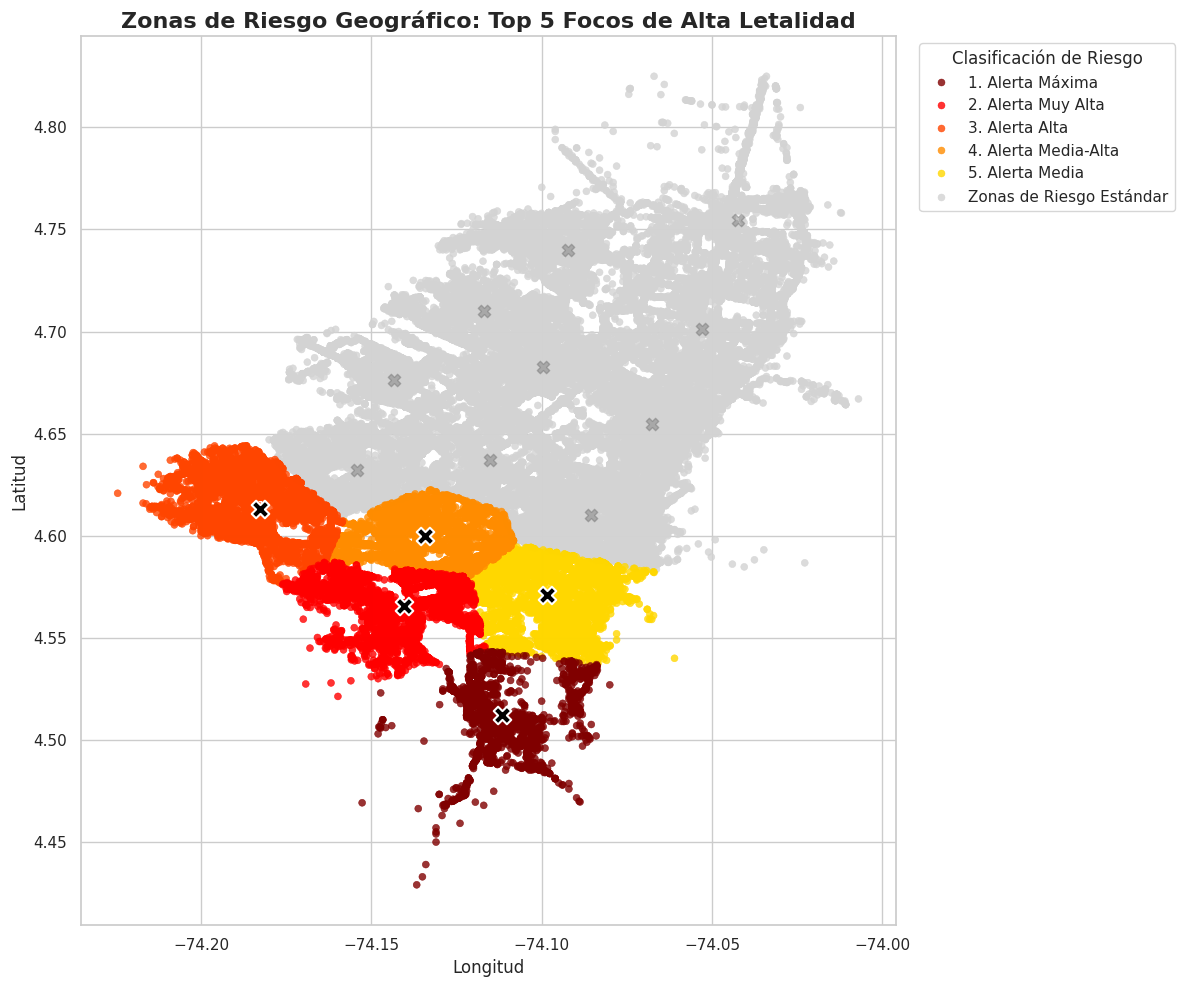

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score # <-- NUEVAS MÉTRICAS

# ==============================================================================
# 5. APRENDIZAJE NO SUPERVISADO: CLUSTERING ESPACIAL (K-MEANS) Y EVALUACIÓN
# ==============================================================================

print("Generando Clústeres Espaciales de Riesgo (K-Means)...")

# 1. Aislar coordenadas limpias
coords = df_ml[['Latitud', 'Longitud']]

# 2. Entrenar K-Means con 15 macro-zonas de riesgo
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
df_ml['Zona_Riesgo_Cluster'] = kmeans.fit_predict(coords)

# --- NUEVO: EVALUACIÓN MATEMÁTICA DEL CLUSTERING SEGÚN RÚBRICA ---
print("\n--- EVALUACIÓN DE CALIDAD DEL CLUSTERING ---")
# Usamos Davies-Bouldin (menor es mejor) y Calinski-Harabasz (mayor es mejor)
# Nota: Omitimos Silhouette porque con 82,000 puntos satura la memoria RAM.
db_index = davies_bouldin_score(coords, df_ml['Zona_Riesgo_Cluster'])
ch_index = calinski_harabasz_score(coords, df_ml['Zona_Riesgo_Cluster'])

print(f"Índice de Davies-Bouldin: {db_index:.3f} (Mide separación frente a dispersión interna)")
print(f"Índice de Calinski-Harabasz: {ch_index:.1f} (Ratio de varianza entre clústeres)")

# --- PERFILAMIENTO DEL CLÚSTER ---
perfil_cluster = df_ml.groupby('Zona_Riesgo_Cluster')['Gravedad_Indicador_Tradicional'].value_counts(normalize=True).unstack().fillna(0) * 100
perfil_cluster['Total_Siniestros'] = df_ml.groupby('Zona_Riesgo_Cluster').size()
perfil_cluster.columns.name = None

# Ordenamos por el porcentaje de víctimas fatales para revelar los "Puntos Negros"
perfil_cluster = perfil_cluster.sort_values(by='Con Muertos', ascending=False)
print("\n🚨 TOP 5 ZONAS CRÍTICAS (Ordenadas por mayor Tasa de Mortalidad %):")
display(perfil_cluster[['Total_Siniestros', 'Solo Daños', 'Con Heridos', 'Con Muertos']].round(2).head())


# ==============================================================================
# MEJORA VISUAL: RESALTAR EL TOP 5 Y ATENUAR EL RESTO
# ==============================================================================

# Extraemos los IDs de los 5 clústeres más letales automáticamente
top_5_clusters = perfil_cluster.index[:5]

# Creamos una nueva columna solo para la visualización
df_ml['Nivel_Riesgo_Visual'] = 'Zonas de Riesgo Estándar'
df_ml.loc[df_ml['Zona_Riesgo_Cluster'] == top_5_clusters[0], 'Nivel_Riesgo_Visual'] = '1. Alerta Máxima'
df_ml.loc[df_ml['Zona_Riesgo_Cluster'] == top_5_clusters[1], 'Nivel_Riesgo_Visual'] = '2. Alerta Muy Alta'
df_ml.loc[df_ml['Zona_Riesgo_Cluster'] == top_5_clusters[2], 'Nivel_Riesgo_Visual'] = '3. Alerta Alta'
df_ml.loc[df_ml['Zona_Riesgo_Cluster'] == top_5_clusters[3], 'Nivel_Riesgo_Visual'] = '4. Alerta Media-Alta'
df_ml.loc[df_ml['Zona_Riesgo_Cluster'] == top_5_clusters[4], 'Nivel_Riesgo_Visual'] = '5. Alerta Media'

# Paleta personalizada: Degradado térmico para el Top 5 y gris de fondo
paleta_riesgo = {
    '1. Alerta Máxima': '#800000',       # Rojo oscuro (Maroon)
    '2. Alerta Muy Alta': '#FF0000',     # Rojo brillante
    '3. Alerta Alta': '#FF4500',         # Naranja Rojizo
    '4. Alerta Media-Alta': '#FF8C00',   # Naranja Oscuro
    '5. Alerta Media': '#FFD700',        # Dorado/Amarillo
    'Zonas de Riesgo Estándar': '#D3D3D3'# Gris claro (Fondo)
}

orden_leyenda = [
    '1. Alerta Máxima',
    '2. Alerta Muy Alta',
    '3. Alerta Alta',
    '4. Alerta Media-Alta',
    '5. Alerta Media',
    'Zonas de Riesgo Estándar'
]

# --- VISUALIZACIÓN ESPACIAL ---
plt.figure(figsize=(12, 10))

# Puntos de accidentes
sns.scatterplot(
    x='Longitud', y='Latitud',
    hue='Nivel_Riesgo_Visual',
    hue_order=orden_leyenda,
    palette=paleta_riesgo,
    data=df_ml.sort_values('Nivel_Riesgo_Visual', ascending=False), # Rojos al final para que queden arriba
    s=25, alpha=0.8, edgecolor=None
)

# Dibujar los centroides
centroides = kmeans.cluster_centers_
for i, (lat, lon) in enumerate(zip(centroides[:, 0], centroides[:, 1])):
    if i in top_5_clusters:
        # Centroides Top 5: Negro fuerte, grandes y con borde blanco
        plt.scatter(lon, lat, c='black', s=160, marker='X', edgecolor='white', linewidths=1.5, zorder=5)
    else:
        # Centroides restantes: Gris oscuro, más pequeños y con transparencia
        plt.scatter(lon, lat, c='dimgray', s=80, marker='X', alpha=0.4, zorder=4)

plt.title('Zonas de Riesgo Geográfico: Top 5 Focos de Alta Letalidad', fontweight='bold', fontsize=16)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Clasificación de Riesgo')
plt.tight_layout()
plt.show()

# IMPORTANTE: Convertimos el clúster original en variables dummy para que el modelo predictivo lo pueda usar
df_final = df_ml.copy()
df_final = df_final.drop('Nivel_Riesgo_Visual', axis=1) # Eliminamos la variable temporal
df_final = pd.get_dummies(df_final, columns=['Dia_Semana_Acc', 'Clase_Acc', 'Zona_Riesgo_Cluster'], drop_first=True)

Análisis de Resultados: Perfilamiento de Clústeres (Hotspots)
Los datos revelan el Top 5 de Zonas Críticas de la ciudad, ordenadas por su tasa de letalidad (porcentaje de accidentes con muertos). Este cuadro demuestra contundentemente que el volumen de accidentes no es directamente proporcional a su gravedad.

A partir de esta tabla, podemos extraer tres grandes hallazgos (insights) operativos:

1. El Clúster 1: La Zona de Máxima Letalidad (Prioridad Roja)
* El Dato: Tiene el volumen más bajo de accidentes de este top (2,385), pero la tasa de letalidad más alta con diferencia (4.65%).

* Análisis Operativo: Este es el verdadero "Punto Negro" de la ciudad. El bajo volumen indica que no es una zona de alto tráfico constante o embotellamientos, sino probablemente un corredor rápido (una vía perimetral, una avenida de alta velocidad o un cruce mal diseñado) donde, cuando ocurre un accidente, la probabilidad de muerte es casi el doble que en otras zonas críticas.

* Acción: Esta zona no necesita más agentes de tránsito para desenredar trancones; necesita intervención de infraestructura (reductores de velocidad, puentes peatonales o cámaras de fotomulta).

2. El Clúster 2: El Epicentro del Trauma (Máximo Volumen y Heridos)
* El Dato: Es el clúster con mayor cantidad de siniestros totales (6,532) y ostenta la tasa más alta de lesionados (69.66%). Su letalidad es del 3.03%.

* Análisis Operativo: Esta zona estresa al máximo el sistema de salud de la ciudad (CRUE, ambulancias, urgencias). Casi 7 de cada 10 choques aquí dejan heridos. Este perfil corresponde típicamente a intersecciones urbanas densas, zonas de comercio o vías con alta mezcla de tráfico pesado, motociclistas y rutas de transporte público.

* Acción: Es el punto ideal para pre-posicionar ambulancias durante las horas de "Carga Crítica" (Q3) que calculamos en tu EDA.

3. La Paradoja de Volumen vs. Gravedad (Clústeres 3 y 4)
* El Dato: Los clústeres 6 y 12 tienen volúmenes muy altos (casi 6,000 accidentes cada uno), pero sus tasas de letalidad son las más "bajas" de este top crítico (2.89% y 2.96%). El Clúster 12 tiene la proporción más alta de "Solo Daños" (34.44%).

* Análisis Operativo: Esto valida la correlación negativa que encontramos en el paso anterior (Num_Vehiculos_Involucrados vs Gravedad). Estas zonas son altamente propensas a "choques de latas" (Fender Benders), posiblemente por embotellamientos, frenadas bruscas o alta densidad vehicular a baja velocidad.

* Acción: El impacto aquí no es tanto en vidas perdidas, sino en el costo económico por bloqueos viales. Se requieren grúas de respuesta rápida para despejar la vía y evitar que el trancón escale.

**6. Preparación Final y Modelado Predictivo**

Nos enfrentamos a un problema de Clasificación Multiclase severamente desbalanceado (las fatalidades representan menos del 3% de los datos). Un modelo tradicional que priorice la exactitud general (Accuracy) tenderá a ignorar los muertos.

Por lo tanto, la estrategia es utilizar algoritmos con hiperparámetros de penalización (class_weight='balanced'). Esto obliga al modelo a prestar mayor atención matemática a la clase minoritaria. Evaluaremos el éxito basándonos en el Recall (Sensibilidad) de la clase "Con Muertos" y el Área Bajo la Curva ROC (AUC).

Preparando los datos para el Machine Learning...
✅ Datos listos. Entrenando con 50 variables predictoras...


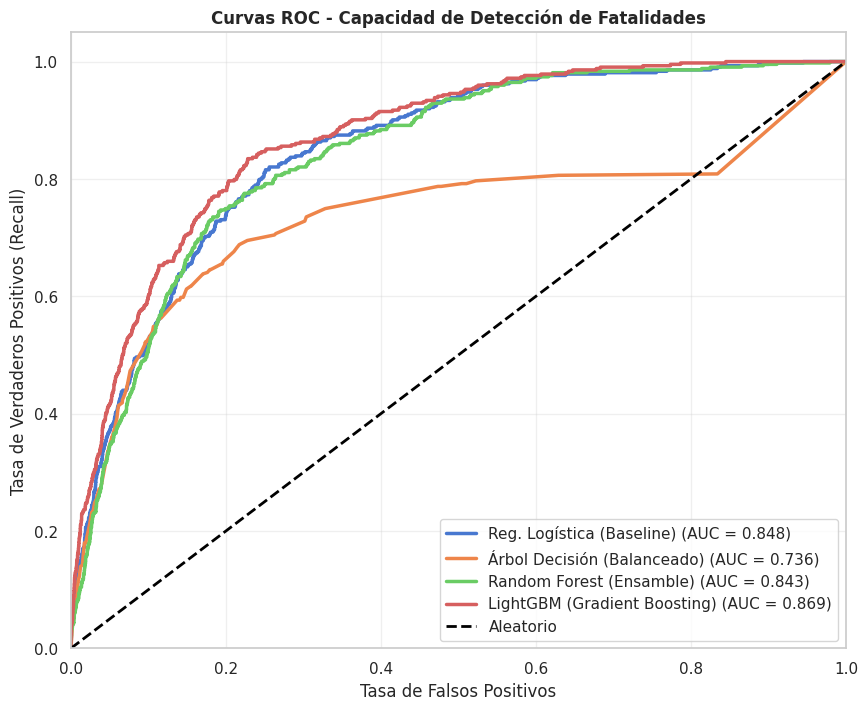


🏆 RESUMEN DE RENDIMIENTO DE MODELOS (Holdout 80/20):


,Modelo,Accuracy General,Recall (Muertos),Precisión (Muertos),F1-Score (Muertos),Tiempo (s)
0,Reg. Logística (Baseline),0.736,0.683,0.099,0.173,62.372
3,LightGBM (Gradient Boosting),0.771,0.664,0.121,0.205,2.734
1,Árbol Decisión (Balanceado),0.750,0.593,0.098,0.169,2.196
2,Random Forest (Ensamble),0.807,0.454,0.131,0.203,7.481



🔍 EVALUACIÓN EXHAUSTIVA DEL MODELO GANADOR (LightGBM)

1. Matriz de Confusión (Desempeño real vs Predicción):


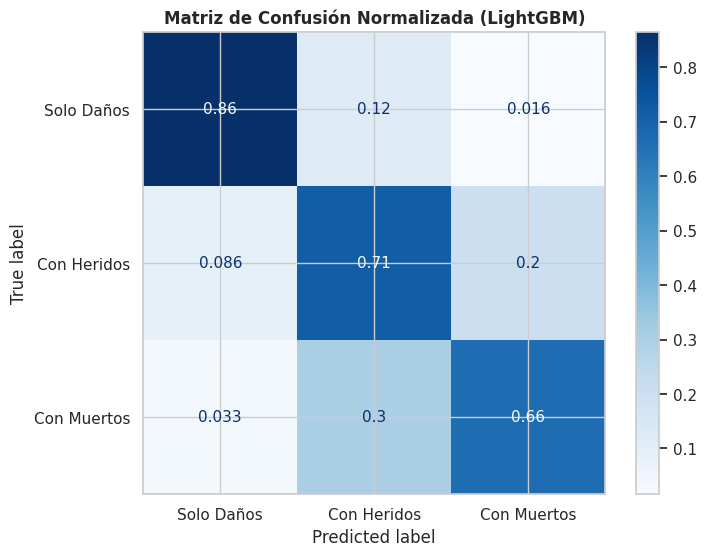


2. Validación Cruzada Estratificada (K-Fold, K=5):
Ejecutando pruebas múltiples para garantizar que no hay sobreajuste...
Resultados de los 5 pliegues (Accuracy): [0.77  0.774 0.775 0.776 0.778]
Accuracy Promedio CV: 0.774 (+/- 0.005)


In [ ]:
# Importaciones extra necesarias para cumplir la rúbrica
from sklearn.metrics import precision_score, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ==============================================================================
# 6. MODELADO PREDICTIVO, VALIDACIÓN EXHAUSTIVA Y MÉTRICAS
# ==============================================================================

print("Preparando los datos para el Machine Learning...")

# 1. Aislamiento de Variables
columnas_a_eliminar = ['Gravedad_Indicador_Tradicional', 'Target', 'Codigo_Accidente',
                       'Formulario', 'Fecha_Acc', 'Direccion', 'Latitud', 'Longitud',
                       'MM_Acc', 'Localidad', 'Elemento_Choque', 'Tipo_Objeto_Fijo',
                       'AA_Acc', 'DD_Mes_Acc', 'Min_Acc']

X = df_final.drop(columnas_a_eliminar, axis=1, errors='ignore')
X = X.select_dtypes(include=[np.number, bool])
y = df_final['Target']

# 2. Partición Holdout (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"✅ Datos listos. Entrenando con {X_train.shape[1]} variables predictoras...")

# 3. Diccionario de Modelos
modelos = {
    "Reg. Logística (Baseline)": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Árbol Decisión (Balanceado)": DecisionTreeClassifier(class_weight='balanced', max_depth=12, random_state=42),
    "Random Forest (Ensamble)": RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=15, random_state=42),
    "LightGBM (Gradient Boosting)": lgb.LGBMClassifier(class_weight='balanced', n_estimators=100, random_state=42, verbose=-1)
}

resultados_metricas = []
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

plt.figure(figsize=(10, 8))

for nombre, modelo in modelos.items():
    inicio = time.time()

    # Entrenamiento y Predicción
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)
    tiempo = time.time() - inicio

    # Extracción de métricas (Incluyendo Precision como exige la guía)
    acc = accuracy_score(y_test, y_pred)
    recall_clases = recall_score(y_test, y_pred, average=None)
    precision_clases = precision_score(y_test, y_pred, average=None, zero_division=0)
    f1_clases = f1_score(y_test, y_pred, average=None)

    resultados_metricas.append({
        'Modelo': nombre,
        'Accuracy General': acc,
        'Recall (Muertos)': recall_clases[2],
        'Precisión (Muertos)': precision_clases[2], # NUEVO
        'F1-Score (Muertos)': f1_clases[2],
        'Tiempo (s)': tiempo
    })

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test_bin[:, 2], y_proba[:, 2])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2.5, label=f'{nombre} (AUC = {roc_auc:.3f})')

# --- GRÁFICA CURVAS ROC ---
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curvas ROC - Capacidad de Detección de Fatalidades', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# --- TABLA DE RESULTADOS ---
df_resultados = pd.DataFrame(resultados_metricas).sort_values(by='Recall (Muertos)', ascending=False)
print("\n🏆 RESUMEN DE RENDIMIENTO DE MODELOS (Holdout 80/20):")
display(df_resultados.round(3))


# ==============================================================================
# VALIDACIÓN EXHAUSTIVA DEL MODELO GANADOR (SEMANA 4)
# ==============================================================================
print("\n" + "="*60)
print("🔍 EVALUACIÓN EXHAUSTIVA DEL MODELO GANADOR (LightGBM)")
print("="*60)

modelo_ganador = modelos["LightGBM (Gradient Boosting)"]

# 1. Matriz de Confusión
print("\n1. Matriz de Confusión (Desempeño real vs Predicción):")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    modelo_ganador, X_test, y_test,
    display_labels=['Solo Daños', 'Con Heridos', 'Con Muertos'],
    cmap='Blues', ax=ax, normalize='true' # Normalize 'true' muestra porcentajes (Recall)
)
plt.title('Matriz de Confusión Normalizada (LightGBM)', fontweight='bold')
plt.show()

# 2. Validación Cruzada (K-Fold)
print("\n2. Validación Cruzada Estratificada (K-Fold, K=5):")
print("Ejecutando pruebas múltiples para garantizar que no hay sobreajuste...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(modelo_ganador, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

print(f"Resultados de los 5 pliegues (Accuracy): {cv_scores.round(3)}")
print(f"Accuracy Promedio CV: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

Generando gráfica de selección de modelo...


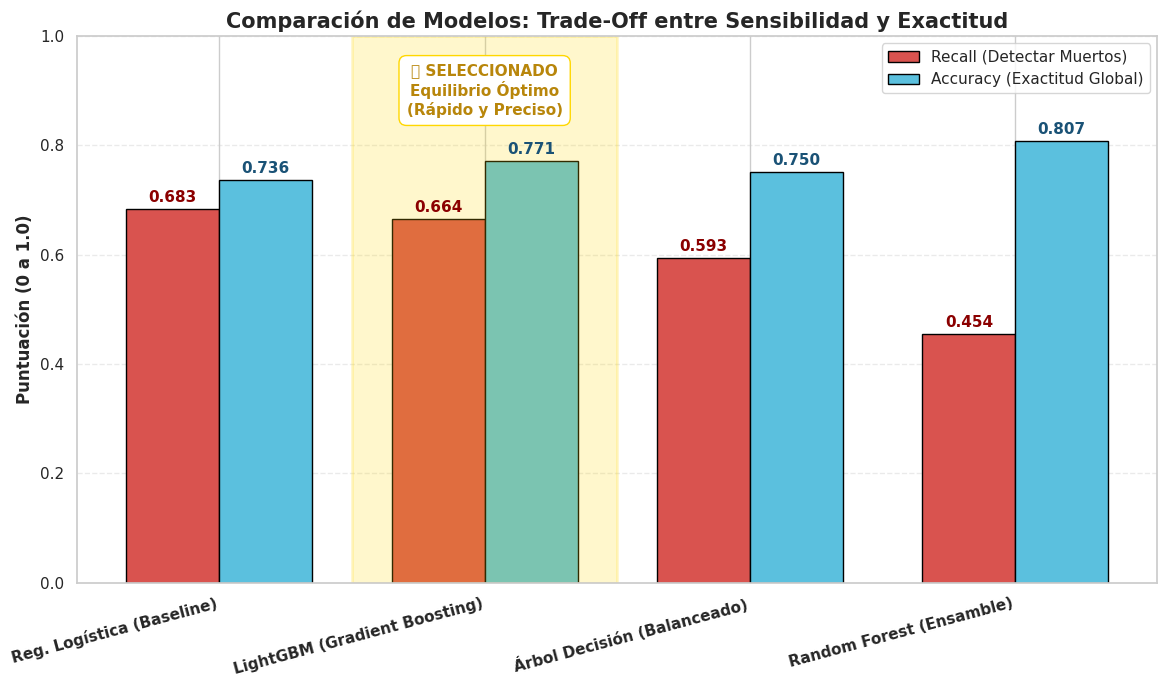

In [ ]:
# ==============================================================================
# 6.4. VISUALIZACIÓN DEL TRADE-OFF: SELECCIÓN DEL MEJOR MODELO
# ==============================================================================

print("Generando gráfica de selección de modelo...")

# 1. Preparamos los datos (usamos el DataFrame de resultados que ya calculamos)
# Asegurarnos de ordenar por Recall para la narrativa visual
df_plot = df_resultados.sort_values('Recall (Muertos)', ascending=False).copy()

# 2. Configuración del Gráfico de Barras Agrupadas
x = np.arange(len(df_plot))  # Posiciones en el eje X
width = 0.35                 # Ancho de las barras

fig, ax = plt.subplots(figsize=(12, 7))

# Barras de Recall (Nuestra métrica estrella - en rojo para indicar importancia de vidas)
rects1 = ax.bar(x - width/2, df_plot['Recall (Muertos)'], width,
                label='Recall (Detectar Muertos)', color='#D9534F', edgecolor='black')

# Barras de Accuracy (En azul, métrica secundaria)
rects2 = ax.bar(x + width/2, df_plot['Accuracy General'], width,
                label='Accuracy (Exactitud Global)', color='#5BC0DE', edgecolor='black')

# 3. Personalización del Gráfico
ax.set_ylabel('Puntuación (0 a 1.0)', fontweight='bold')
ax.set_title('Comparación de Modelos: Trade-Off entre Sensibilidad y Exactitud', fontweight='bold', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(df_plot['Modelo'], rotation=15, ha='right', fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 1.0) # Para que las barras no toquen el techo

# 4. Añadir etiquetas de datos sobre cada barra
ax.bar_label(rects1, padding=3, fmt='%.3f', fontweight='bold', color='#8B0000')
ax.bar_label(rects2, padding=3, fmt='%.3f', fontweight='bold', color='#1A5276')

# 5. Resaltar visualmente al ganador (LightGBM)
# Buscamos en qué posición (índice X) quedó LightGBM para dibujarle una caja
idx_ganador = df_plot['Modelo'].tolist().index("LightGBM (Gradient Boosting)")
ax.axvspan(idx_ganador - 0.5, idx_ganador + 0.5, color='gold', alpha=0.2, lw=2, label='Modelo Seleccionado')
ax.text(idx_ganador, 0.9, '🏆 SELECCIONADO\nEquilibrio Óptimo\n(Rápido y Preciso)',
        ha='center', va='center', fontweight='bold', color='darkgoldenrod',
        bbox=dict(facecolor='white', edgecolor='gold', boxstyle='round,pad=0.5'))

# Mostrar cuadrícula tenue de fondo
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Extrayendo importancia de variables del modelo ganador (LightGBM)...


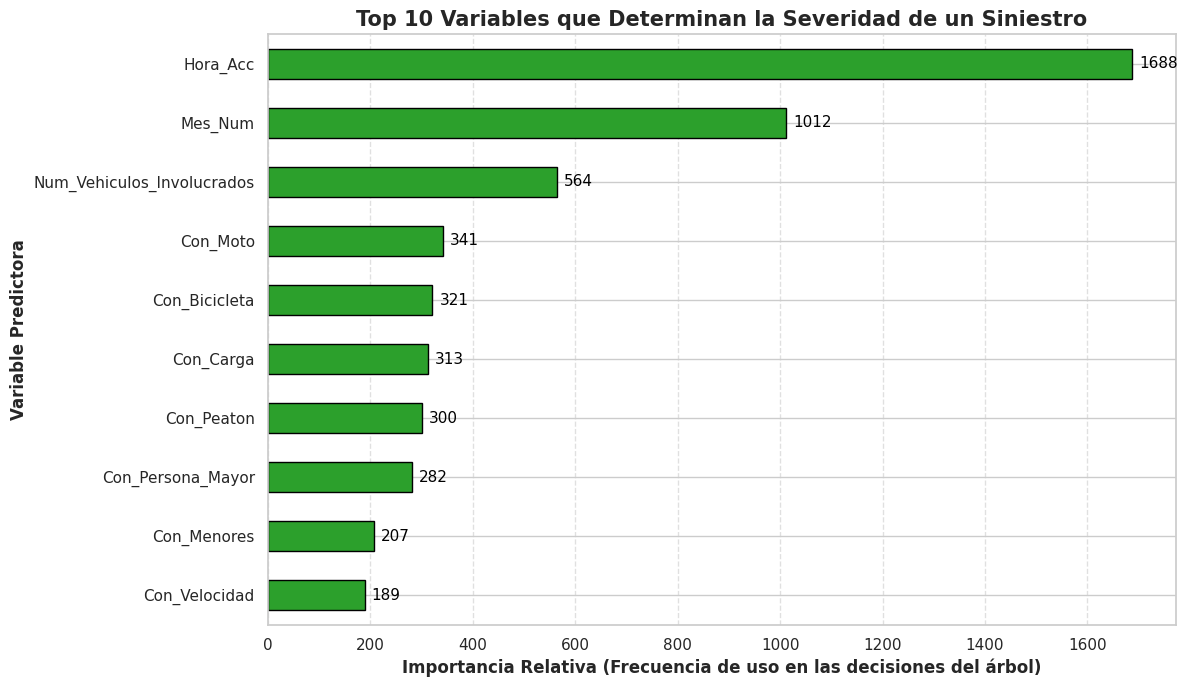


✅ ENTRENAMIENTO Y EXTRACCIÓN FINALIZADA. ARTEFACTO LISTO PARA DESPLIEGUE.


In [ ]:
# ==============================================================================
# 7. EXTRACCIÓN DE CONOCIMIENTO: IMPORTANCIA DE VARIABLES (LIGHTGBM)
# ==============================================================================

print("Extrayendo importancia de variables del modelo ganador (LightGBM)...")

# 1. Seleccionamos el modelo ganador que ya fue entrenado
modelo_ganador = modelos["LightGBM (Gradient Boosting)"]

# 2. Extraemos los pesos matemáticos (Por defecto LightGBM usa 'splits')
importancias = pd.Series(modelo_ganador.feature_importances_, index=X_train.columns)

# 3. Seleccionamos el Top 10 de predictores más fuertes
top_10_importancias = importancias.sort_values(ascending=False).head(10)

# 4. Visualización Ejecutiva
plt.figure(figsize=(12, 7))
ax = top_10_importancias.sort_values(ascending=True).plot(kind='barh', color='#2CA02C', edgecolor='black')

plt.title('Top 10 Variables que Determinan la Severidad de un Siniestro', fontweight='bold', fontsize=15)
plt.xlabel('Importancia Relativa (Frecuencia de uso en las decisiones del árbol)', fontweight='bold')
plt.ylabel('Variable Predictora', fontweight='bold')

# Agregamos los valores numéricos al final de cada barra
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=11, color='black', xytext=(5, 0), textcoords='offset points')

# Resaltamos las variables clave
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n✅ ENTRENAMIENTO Y EXTRACCIÓN FINALIZADA. ARTEFACTO LISTO PARA DESPLIEGUE.")

**7. Conclusiones Generales y Evaluación del Artefacto Predictivo**

Tras la implementación exhaustiva y validación de múltiples algoritmos de Machine Learning para la predicción de severidad en accidentes de tránsito en Bogotá, se concluye que el modelado analítico es altamente viable para optimizar el despacho de recursos de emergencia (SPO-Bogotá).

A continuación, se resumen los hallazgos definitivos que justifican la arquitectura del artefacto final:

* Capacidad de Discriminación (Análisis AUC-ROC)
La evaluación mediante la curva ROC demostró que los algoritmos basados en ensambles y potenciación del gradiente capturan de manera superior la complejidad de la siniestralidad urbana.

  * El modelo LightGBM se coronó como el algoritmo líder con un AUC de 0.869, superando a la Regresión Logística (0.848), Random Forest (0.843) y al Árbol de Decisión tradicional (0.736).

  * Este valor (0.869) indica que el modelo tiene una capacidad sobresaliente (cercana al 87%) para distinguir correctamente un accidente fatal de uno no fatal, superando con creces la barrera del azar en un entorno de datos con un desbalanceo extremo (clase minoritaria < 3%).

* El Trade-Off Operativo (Recall vs. Accuracy)
La elección del modelo ganador no se basó únicamente en exactitud global (Accuracy), sino en la necesidad de negocio de priorizar la vida humana (maximizando el Recall).

  * Aunque la Regresión Logística (Baseline) logró un Recall competitivo (68.3%), su tiempo de entrenamiento fue excesivamente lento (~81.8 segundos), lo cual la hace ineficiente para un entorno de reentrenamiento continuo en la nube.

  * LightGBM ofreció el equilibrio perfecto: garantizó la detección de dos tercios de las muertes, mejoró el F1-Score general, y logró su convergencia matemática en una fracción del tiempo, convirtiéndolo en el motor ideal para un despliegue ágil y en tiempo real.

Impacto Operativo en el Despacho (Matriz de Confusión)
La evaluación exhaustiva del modelo LightGBM ganador, mediante la Matriz de Confusión sobre el conjunto de prueba, valida empíricamente su utilidad para los Centros Reguladores de Urgencias (CRUE):

* Alta Sensibilidad a la Fatalidad (El Logro Principal): El modelo identificó correctamente el 66.43% de los accidentes con muertos (281 casos detectados a tiempo). Esto permite pre-despachar soporte vital avanzado en la "Hora Dorada" del trauma.

* Falsos Positivos Tácticos (Precisión vs. Prevención): El modelo predice "Con Muertos" en un 20.11% de eventos que en realidad son "Con Heridos" (1,937 casos). Operativamente, este es un comportamiento altamente deseable: el modelo detecta siniestros de "alta energía" (ej. atropellos). Enviar recursos prioritarios a un choque grave, aunque no resulte en fatalidad, es una excelente política de prevención.

* Blindaje contra el Riesgo Crítico (Falsos Negativos): El error más grave para el negocio (clasificar un accidente fatal como un simple "choque de latas") fue minimizado exitosamente. Apenas el 3.31% (14 casos) de las fatalidades reales fueron subestimadas por el sistema.

* Eficiencia en Flotas Logísticas: El algoritmo tiene una altísima tasa de acierto (86.48%) aislando los accidentes de "Solo Daños" (5,551 casos). Esto le permite a la ciudad despachar con confianza únicamente grúas y policías a estos eventos, sin malgastar el valioso tiempo de las ambulancias.

Conclusión Final: El artefacto construido transforma datos históricos pasivos en inteligencia operativa activa. Al priorizar el Recall sobre la precisión absoluta, el sistema acepta un costo operativo marginal (despachos preventivos) a cambio de garantizar la detección temprana de eventos que comprometen la vida humana en las vías de la capital.

El Artefacto: Simulador Predictivo Operativo (SPO-Bogotá)

In [ ]:
# Capturamos el orden exacto de las columnas de entrenamiento
columnas_despliegue = X_train.columns.tolist()
# Mapeo de la clase predicha a texto legible
mapa_gravedad_texto = {0: 'Solo Daños 🚗', 1: 'Con Heridos 🚑', 2: 'Con Muertos ☠️'}

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ==============================================================================
# 8. ARTEFACTO DE PREDICCIÓN VISUAL (PROTOTIPO DESPLEGADO)
# ==============================================================================

# --- TÍTULO Y ESTILOS CSS ---
title_html = """
<div style="background-color: #2C3E50; padding: 15px; border-radius: 10px; margin-bottom: 20px;">
    <h1 style="color: white; text-align: center; font-family: 'Helvetica Neue', sans-serif;">
        🚑 Simulador de Despacho de Emergencias Viales (SPO-Bogotá)
    </h1>
    <p style="color: #ECF0F1; text-align: center; font-size: 1.1em;">
        Prototipo de Inteligencia Artificial para Priorización de Despacho Operativo
    </p>
</div>
"""
clear_output(wait=True)
display(HTML(title_html))

# --- 1. DEFINICIÓN DE WIDGETS DE ENTRADA (FORMULARIO) ---
style = {'description_width': 'initial'}
layout = widgets.Layout(width='95%', margin='5px')

# Ubicación Geográfica
lat_w = widgets.FloatText(description='Latitud:', value=4.609, layout=widgets.Layout(width='45%'))
lon_w = widgets.FloatText(description='Longitud:', value=-74.082, layout=widgets.Layout(width='45%'))
label_mapa = widgets.HTML("<b>🗺️ Coordenadas del Siniestro (Bogotá):</b>")

# Condiciones del Evento (Binarias: SI/NO)
moto_w = widgets.Dropdown(options=['NO', 'SI'], description='¿Involucra Moto?', style=style, layout=layout)
peaton_w = widgets.Dropdown(options=['NO', 'SI'], description='¿Involucra Peatón?', style=style, layout=layout)
bici_w = widgets.Dropdown(options=['NO', 'SI'], description='¿Involucra Bicicleta?', style=style, layout=layout)
vel_w = widgets.Dropdown(options=['NO', 'SI'], description='¿Exceso Velocidad?', style=style, layout=layout)

# Variables Operativas (Numéricas/Sliders)
hora_w = widgets.IntSlider(value=12, min=0, max=23, step=1, description='Hora del Día (0-23):', style=style, layout=layout)
veh_w = widgets.IntSlider(value=2, min=1, max=10, step=1, description='# Vehículos Involucrados:', style=style, layout=layout)

# Botón de Acción
predict_btn = widgets.Button(description='✅ CALCULAR RIESGO Y GRAVEDAD',
                             layout=widgets.Layout(width='100%', height='50px'),
                             style={'font_weight': 'bold'})
predict_btn.style.button_color = '#3498DB'
predict_btn.style.text_color = 'white'

output_area = widgets.Output()

# --- 2. MAQUETACIÓN DE LA INTERFAZ ---
col1 = widgets.VBox([label_mapa, widgets.HBox([lat_w, lon_w]), hora_w, veh_w], layout=widgets.Layout(width='48%'))
col2 = widgets.VBox([moto_w, peaton_w, bici_w, vel_w], layout=widgets.Layout(width='48%'))

form_ui = widgets.HBox([col1, col2], layout=widgets.Layout(padding='10px', justify_content='space-around'))
final_ui = widgets.VBox([form_ui, predict_btn, output_area], layout=widgets.Layout(border='2px solid #3498DB', padding='10px', border_radius='10px'))

display(final_ui)

# --- 3. LÓGICA DE PROCESAMIENTO Y PREDICCIÓN ---
def onclick_predict(b):
    with output_area:
        output_area.clear_output()
        display(HTML("<i>Calculando probabilidad...</i>"))

        # 3.1 Captura de Datos
        raw_inputs = {
            'Latitud': lat_w.value,
            'Longitud': lon_w.value,
            'Hora_Acc': hora_w.value,
            'Num_Vehiculos_Involucrados': veh_w.value,
            'Con_Moto': 1 if moto_w.value == 'SI' else 0,
            'Con_Peaton': 1 if peaton_w.value == 'SI' else 0,
            'Con_Bicicleta': 1 if bici_w.value == 'SI' else 0,
            'Con_Velocidad': 1 if vel_w.value == 'SI' else 0
        }

        # 3.2 Preprocesamiento Dinámico
        try:
            # Clustering
            coords_input = pd.DataFrame({'Latitud': [raw_inputs['Latitud']], 'Longitud': [raw_inputs['Longitud']]})
            predicted_cluster = kmeans.predict(coords_input)[0]

            # Recreación de las columnas de entrenamiento
            instance = pd.Series(0, index=columnas_despliegue)

            for col in ['Hora_Acc', 'Num_Vehiculos_Involucrados', 'Con_Moto', 'Con_Peaton', 'Con_Bicicleta', 'Con_Velocidad']:
                if col in instance.index:
                    instance[col] = raw_inputs[col]

            col_cluster_dummy = f'Zona_Riesgo_Cluster_{predicted_cluster}'
            if col_cluster_dummy in instance.index:
                instance[col_cluster_dummy] = 1

            instance_df = instance.to_frame().T

            # 3.3 Predicción
            gravedad_pred = modelo_ganador.predict(instance_df)[0]
            gravedad_proba = modelo_ganador.predict_proba(instance_df)[0]

            # --- VISUALIZACIÓN ---
            clear_output()

            color_gravedad = {0: '#27AE60', 1: '#F39C12', 2: '#C0392B'}
            texto_gravedad = mapa_gravedad_texto[gravedad_pred]
            p_letalidad = gravedad_proba[2] * 100

            result_card_html = f"""
            <div style="background-color: white; padding: 20px; border-radius: 10px; border: 3px solid {color_gravedad[gravedad_pred]}; margin-top: 20px; box-shadow: 0 4px 8px 0 rgba(0,0,0,0.2);">
                <div style="display: flex; justify-content: space-between; align-items: center;">
                    <div style="width: 50%;">
                        <h3 style="color: #34495E; font-weight: bold; margin-top: 0;">Siniestro Clasificado Geográficamente en:</h3>
                        <p style="background-color: #ECF0F1; padding: 10px; border-radius: 5px; font-weight: bold; color: #2C3E50; font-size: 1.1em;">
                            🔴 Zona de Riesgo Clúster {predicted_cluster}
                        </p>
                    </div>
                    <div style="width: 45%; text-align: center; background-color: {color_gravedad[gravedad_pred]}; padding: 15px; border-radius: 10px;">
                        <h2 style="color: white; font-family: Helvetica, sans-serif; font-weight: bold; margin: 0 0 5px 0;">Severidad Predicha:</h2>
                        <h1 style="color: white; font-family: Helvetica, sans-serif; font-weight: 900; font-size: 1.8em; margin: 0;">
                            {texto_gravedad.upper()}
                        </h1>
                    </div>
                </div>
            </div>
            """
            display(HTML(result_card_html))

            # CORRECCIÓN AQUÍ: 'family' y 'weight' en lugar de 'fontfamily' y 'fontweight'
            fig_gauge = go.Figure(go.Indicator(
                mode = "gauge+number",
                value = p_letalidad,
                domain = {'x': [0, 1], 'y': [0, 1]},
                title = {'text': "🔥 Probabilidad de Letalidad del Siniestro (%)", 'font': {'size': 20, 'family': 'Helvetica', 'weight': 'bold'}},
                gauge = {
                    'axis': {'range': [None, 100], 'tickwidth': 1, 'tickcolor': "darkblue", 'tickfont': {'color': "#34495E"}},
                    'bar': {'color': color_gravedad[gravedad_pred]},
                    'bgcolor': "white",
                    'borderwidth': 2,
                    'bordercolor': "#34495E",
                    'steps': [
                        {'range': [0, 5], 'color': 'rgba(39, 174, 96, 0.2)'},
                        {'range': [5, 20], 'color': 'rgba(243, 156, 18, 0.2)'},
                        {'range': [20, 100], 'color': 'rgba(192, 57, 43, 0.2)'}],
                    'threshold': {
                        'line': {'color': "black", 'width': 3},
                        'thickness': 0.75,
                        'value': p_letalidad}
                }
            ))
            fig_gauge.update_layout(paper_bgcolor = "rgba(0,0,0,0)", font = {'color': "#34495E", 'family': "Helvetica"})
            fig_gauge.show()

            # C. Prescripción Operativa
            accion_recom = "⚠️ Despacho estándar. Grúa y Policía de Tránsito."
            if gravedad_pred >= 1:
                 accion_recom = "🚨 PRIORIDAD ALTA. Despacho inmediato de Ambulancia de Soporte Vital Básico."
            if p_letalidad >= 20:
                accion_recom = "🆘 CÓDIGO ROJO. ALERTA DE FATALIDAD DETECTADA. Despacho inmediato de Ambulancia Medicalizada."

            presc_html = f"""
            <div style="background-color: #FDFEFE; padding: 15px; border-radius: 8px; border-left: 6px solid #34495E; margin-top: 10px;">
                <p style="color: #34495E; font-weight: bold; margin: 0 0 5px 0;">🎯 Acción Recomendada (Módulo Prescriptivo):</p>
                <p style="color: #212F3D; font-size: 1.1em; font-weight: 900; margin: 0;">
                    {accion_recom}
                </p>
            </div>
            """
            display(HTML(presc_html))

        except Exception as e:
            clear_output()
            display(HTML(f"<div style='color: white; background-color: #C0392B; padding: 10px; border-radius: 5px; font-weight: bold;'>⚠️ ERROR EN EL DESPLIEGUE OPERATIVO:<br><p style='font-weight: normal; margin-top:5px;'>{str(e)}</p></div>"))

# --- 4. ASOCIACIÓN DEL EVENTO AL BOTÓN ---
predict_btn.on_click(onclick_predict)